# Test Circadian Analysis

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import powerlaw, truncnorm, ks_2samp
import powerlaw
import random

# Simple trapezoid integration for NumPy 2.0+ compatibility
def trapz(y, x):
    return np.sum((x[1:] - x[:-1]) * (y[1:] + y[:-1]) / 2)

## Generate artificial Dataset:

In [105]:
def generate_synthetic_sms(
    # Parámetros del proceso primario
    Nw=10,              # ráfagas por semana
    rho_a=6.0,          # mensajes por hora dentro de ráfaga
    mean_Na=2,          # media de mensajes adicionales por ráfaga
    
    # Distribuciones circadianas/semanales (vectores o franjas)
    pd_t=None,          # distribución horaria (24 bins), o None para usar active_hours
    pw_t=None,          # distribución semanal (7 bins), o None para usar active_days
    active_hours=(9,22), # solo si pd_t=None
    active_days=(0,4),   # solo si pw_t=None
    
    # Duración de la simulación
    n_weeks=52,
    
    seed=42
):
    """
    Genera timestamps sintéticos siguiendo el cascading NHPP
    
    Args:
        pd_t: array de 24 elementos con distribución horaria, o None para construirla de active_hours
        pw_t: array de 7 elementos con distribución semanal, o None para construirla de active_days
    
    Returns:
        timestamps: array de timestamps en segundos
        true_params: diccionario con los parámetros reales usados
        burst_labels: array indicando a qué ráfaga pertenece cada mensaje
    """
    np.random.seed(seed)
    
    total_hours = n_weeks * 7 * 24
    
    # ── 1. Construir o validar pd(t) y pw(t) ──────────────────────────────
    
    if pd_t is None:
        # Construir a partir de active_hours
        pd_t_arr = np.zeros(24)
        for h in range(active_hours[0], active_hours[1]):
            pd_t_arr[h] = 1.0
        pd_t_arr = pd_t_arr / pd_t_arr.sum()
    else:
        pd_t_arr = np.asarray(pd_t)
        assert len(pd_t_arr) == 24, "pd_t debe tener 24 elementos"
        pd_t_arr = pd_t_arr / pd_t_arr.sum()  # normalizar
    
    if pw_t is None:
        # Construir a partir de active_days
        pw_t_arr = np.zeros(7)
        for d in range(active_days[0], active_days[1] + 1):
            pw_t_arr[d] = 1.0
        pw_t_arr = pw_t_arr / pw_t_arr.sum()
    else:
        pw_t_arr = np.asarray(pw_t)
        assert len(pw_t_arr) == 7, "pw_t debe tener 7 elementos"
        pw_t_arr = pw_t_arr / pw_t_arr.sum()  # normalizar
    
    # ── 2. Generar inicios de ráfagas (proceso primario) ────────
    
    timestamps = []
    burst_labels = []
    burst_id = 0
    
    # Número total de ráfagas
    n_bursts = int(Nw * n_weeks)
    
    # Muestrear días y horas para cada ráfaga (una sola vez para n_bursts total)
    burst_days = np.random.choice(7, size=n_bursts, p=pw_t_arr)
    burst_hours = np.random.choice(24, size=n_bursts, p=pd_t_arr)
    burst_minutes = np.random.uniform(0, 60, size=n_bursts)
    
    # Convertir a timestamps en horas desde el inicio
    week_indices = np.random.choice(n_weeks, size=n_bursts)  # en qué semana
    burst_times_hours = (
        week_indices * 7 * 24 +
        burst_days * 24 +
        burst_hours +
        burst_minutes / 60
    )
    burst_times_hours = np.sort(burst_times_hours)
    
    # ── 3. Para cada ráfaga, generar mensajes adicionales ────────
    
    for burst_start_h in burst_times_hours:
        
        # Este mensaje inicia la ráfaga
        timestamps.append(burst_start_h * 3600)
        burst_labels.append(burst_id)
        
        # Na mensajes adicionales (Poisson)
        Na = np.random.poisson(mean_Na)
        
        t = burst_start_h
        for _ in range(Na):
            # IET dentro de la ráfaga ~ Exponencial(rho_a)
            dt = np.random.exponential(1.0 / rho_a)
            t += dt
            timestamps.append(t * 3600)
            burst_labels.append(burst_id)
        
        burst_id += 1
    
    timestamps = np.array(timestamps)
    burst_labels = np.array(burst_labels)
    
    # Ordenar por tiempo
    sort_idx = np.argsort(timestamps)
    timestamps = timestamps[sort_idx]
    burst_labels = burst_labels[sort_idx]
    
    true_params = {
        'Nw': Nw,
        'rho_a': rho_a,
        'mean_Na': mean_Na,
        'pd_t': pd_t_arr,
        'pw_t': pw_t_arr,
        'active_hours': active_hours if pd_t is None else None,
        'active_days': active_days if pw_t is None else None,
        'n_bursts_total': n_bursts
    }
    
    return timestamps, burst_labels, true_params


=== DATOS SINTÉTICOS GENERADOS ===
Mensajes generados: 293
Ráfagas generadas:  149
Media mensajes/ráfaga: 1.97

Parámetros reales usados:
  rho_a = 37.6108
  Nw = 37.3732
  mean_Na = 1


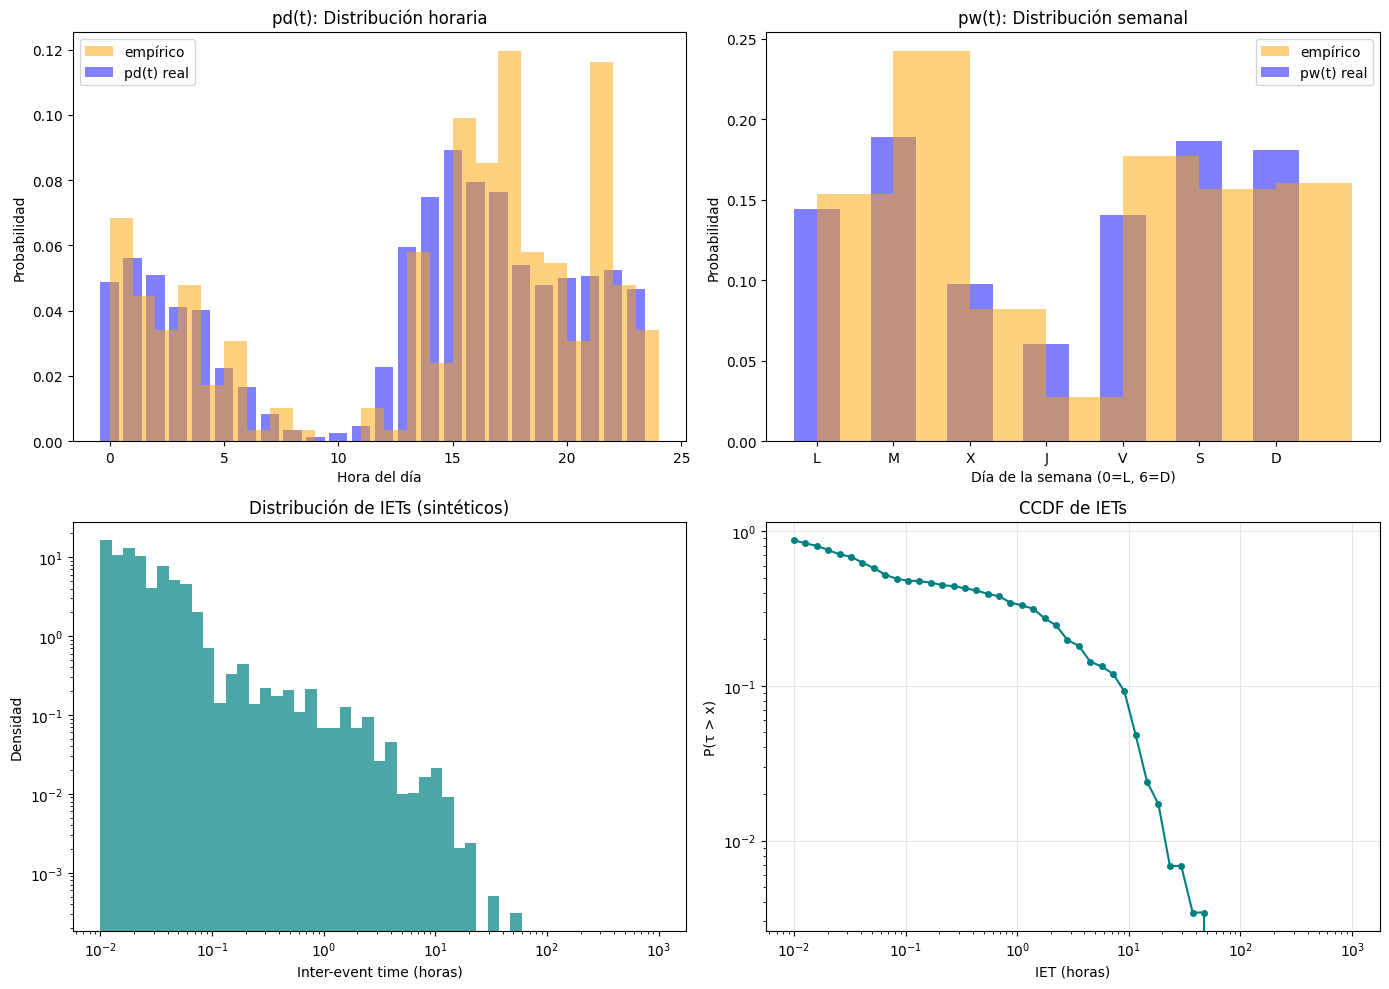

In [106]:
# ── Parámetros reales del usuario (del notebook cycles_all.ipynb) ────────

real_params_user = {
    'rho_a': 37.6108,
    'Nw': 37.3732,
    'A_best': 0.6264,
    'pd_t': np.array([0.04883963, 0.05611361, 0.05091791, 0.04121926, 0.04018012, 0.02251472,
                      0.01662626, 0.00831313, 0.0034638,  0.00138552, 0.00242466, 0.00450294,
                      0.0228611,  0.05957742, 0.07481815, 0.08936612, 0.07932109, 0.07620367,
                      0.05403533, 0.04780048, 0.04987877, 0.05057153, 0.05230343, 0.04676134]),
    'pw_t': np.array([0.1444406,  0.18912366, 0.09767925, 0.06061656, 0.14063041, 0.18635262, 0.18115691]),
    'mean_Na': 1  # Cambiar para ver 
}

# ── Generar datos sintéticos con esos parámetros ────────────────────────

timestamps, true_bursts, true_params = generate_synthetic_sms(
    Nw=real_params_user['Nw'],
    rho_a=real_params_user['rho_a'],
    mean_Na=real_params_user['mean_Na'],
    pd_t=real_params_user['pd_t'],
    pw_t=real_params_user['pw_t'],
    n_weeks=4,
    seed=42
)

print(f"=== DATOS SINTÉTICOS GENERADOS ===")
print(f"Mensajes generados: {len(timestamps)}")
print(f"Ráfagas generadas:  {true_params['n_bursts_total']}")
print(f"Media mensajes/ráfaga: {len(timestamps)/true_params['n_bursts_total']:.2f}")
print(f"\nParámetros reales usados:")
print(f"  rho_a = {real_params_user['rho_a']:.4f}")
print(f"  Nw = {real_params_user['Nw']:.4f}")
print(f"  mean_Na = {real_params_user['mean_Na']}")

# ── Convertir a horas para el análisis ─────────────────────────────────────

events_hours = timestamps / 3600.0

# ── Visualizar pd(t) y pw(t) de los datos generados ─────────────────────

times_dt = pd.to_datetime(timestamps, unit='s', origin=pd.Timestamp('2024-01-01'))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# pd(t) real vs generado
hours_generated = times_dt.hour
axes[0,0].bar(range(24), true_params['pd_t'], alpha=0.5, label='pd(t) real', color='blue')
axes[0,0].hist(hours_generated, bins=24, range=(0,24), density=True, alpha=0.5, label='empírico', color='orange')
axes[0,0].set_title('pd(t): Distribución horaria')
axes[0,0].set_xlabel('Hora del día')
axes[0,0].set_ylabel('Probabilidad')
axes[0,0].legend()

# pw(t) real vs generado
weekdays_generated = times_dt.dayofweek
axes[0,1].bar(range(7), true_params['pw_t'], alpha=0.5, label='pw(t) real', color='blue', width=0.6)
axes[0,1].hist(weekdays_generated, bins=7, range=(0,7), density=True, alpha=0.5, label='empírico', color='orange')
axes[0,1].set_title('pw(t): Distribución semanal')
axes[0,1].set_xlabel('Día de la semana (0=L, 6=D)')
axes[0,1].set_ylabel('Probabilidad')
axes[0,1].set_xticks(range(7))
axes[0,1].set_xticklabels(['L','M','X','J','V','S','D'])
axes[0,1].legend()

# Distribución de IETs
iets_hours = np.diff(events_hours)
log_bins = np.logspace(-2, 3, 50)
axes[1,0].hist(iets_hours, bins=log_bins, density=True, alpha=0.7, color='teal')
axes[1,0].set_xscale('log')
axes[1,0].set_yscale('log')
axes[1,0].set_xlabel('Inter-event time (horas)')
axes[1,0].set_ylabel('Densidad')
axes[1,0].set_title('Distribución de IETs (sintéticos)')

# CCDF
ccdf = np.array([np.mean(iets_hours > b) for b in log_bins])
axes[1,1].loglog(log_bins, ccdf, 'o-', color='teal', markersize=4)
axes[1,1].set_xlabel('IET (horas)')
axes[1,1].set_ylabel('P(τ > x)')
axes[1,1].set_title('CCDF de IETs')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [107]:
# Nota: Esta celda ha sido reemplazada por el pipeline completo de validación.
# Los parámetros ahora se estiman automáticamente usando simulated_annealing.
# Ver celdas anteriores: "RE-ESTIMACIÓN DE PARÁMETROS" y "COMPARACIÓN DE PARÁMETROS"
print("✓ Pipeline de validación completado. Revisa las salidas anteriores.")


✓ Pipeline de validación completado. Revisa las salidas anteriores.


## Testear códigos

In [108]:

def compute_model_params(events, active_config):
    """
    events: array de tiempos en HORAS (relative to start).
    active_config: array booleano, True = mismo active interval que el evento anterior
    """
    # Separar inter-event times dentro y fuera de active intervals
    iets = np.diff(events)  # en horas
    
    iet_active = iets[active_config[1:]]   # dentro de cascadas
    iet_between = iets[~active_config[1:]] # entre cascadas
    
    # ρa: tasa dentro de active intervals (si es Poisson, es 1/mean)
    rho_a = 1.0 / np.mean(iet_active) if len(iet_active) > 0 else 0
    
    # Nw: número medio de active intervals por semana
    n_active_intervals = np.sum(~active_config[1:]) + 1
    total_weeks = (events[-1] - events[0]) / (7 * 24)  # events en horas, semanas en horas
    Nw = n_active_intervals / total_weeks if total_weeks > 0 else 0
    
    # pd(t) y pw(t) a partir de los inicios de active intervals
    starts_idx = np.where(~active_config[1:])[0] + 1
    start_times = events[starts_idx]  # ya en horas
    
    # Hora del día (0-24) y día de la semana (0-7)
    hours = start_times % 24
    weekdays = (start_times / 24) % 7
    
    # Histogramas: contar y normalizar a probabilidad discreta
    pd_counts, _ = np.histogram(hours, bins=24, range=(0, 24))
    pw_counts, _ = np.histogram(weekdays, bins=7, range=(0, 7))
    pd_t = pd_counts.astype(float) / pd_counts.sum() if pd_counts.sum() > 0 else np.zeros(24)
    pw_t = pw_counts.astype(float) / pw_counts.sum() if pw_counts.sum() > 0 else np.zeros(7)
    
    return rho_a, Nw, pd_t, pw_t

def area_test_statistic(empirical_iet, model_iet, n_bins=100, eps=1e-6):
    """
    Área entre CCDFs empírica y del modelo (en escala log).
    Esta versión evita llamadas a `np.trapz` y protege contra valores no positivos o NaN.
    """
    emp = np.asarray(empirical_iet)
    mod = np.asarray(model_iet)
    # Filtrar valores no finitos y no positivos (log escala requiere >0)
    emp = emp[np.isfinite(emp) & (emp > 0)]
    mod = mod[np.isfinite(mod) & (mod > 0)]
    if len(emp) == 0 or len(mod) == 0:
        return np.inf
    # límites seguros para la malla logarítmica
    lo = max(emp.min(), mod.min(), eps)
    hi = max(emp.max(), mod.max(), lo * 10)
    log_bins = np.logspace(np.log10(lo), np.log10(hi), n_bins)
    # CCDF = P(X > b)
    ccdf_emp = np.array([np.mean(emp > b) for b in log_bins])
    ccdf_mod = np.array([np.mean(mod > b) for b in log_bins])
    # Usar la implementación local `trapz(y, x)` definida arriba
    return trapz(np.abs(ccdf_emp - ccdf_mod), np.log(log_bins))

def simulate_cascading_nhpp(rho_a, Nw, pd_t, pw_t, p_Na, 
                             total_hours, n_samples):
    """
    Simula el cascading nonhomogeneous Poisson process
    """
    # Reconstruir ρ(t) = Nw * pd(t) * pw(t)
    # Simplificación: muestrear inicio de active intervals
    # y luego añadir Na eventos adicionales con tasa rho_a
    
    events = []
    t = 0
    week_hours = 7 * 24
    
    while t < total_hours:
        # Tiempo hasta próximo active interval
        # Usando inversión de la CDF de ρ(t) (simplificado)
        rate_mean = Nw / week_hours  # tasa media por hora
        dt = np.random.exponential(1.0 / rate_mean)
        t += dt
        
        if t >= total_hours:
            break
            
        events.append(t)
        
        # Na eventos adicionales en esta cascada
        Na = np.random.choice(len(p_Na), p=p_Na/p_Na.sum())
        for _ in range(Na):
            dt_a = np.random.exponential(1.0 / rho_a)
            t += dt_a
            if t < total_hours:
                events.append(t)
    
    return np.array(sorted(events))[:n_samples]

def simulated_annealing(events_hours, n_iter=5000, T_init=1.0, cooling=0.95):
    """
    SA para encontrar la configuración óptima de active intervals
    """
    N = len(events_hours)
    iets = np.diff(events_hours)
    
    # Inicializar: separar en active intervals donde IET < umbral
    threshold = np.median(iets)
    config = iets < threshold  # True = mismo active interval
    
    # Calcular p(Na) inicial
    def get_pNa(config, max_Na=10):
        na_counts = []
        count = 0
        for c in config:
            if c:
                count += 1
            else:
                na_counts.append(count)
                count = 0
        na_counts.append(count)
        hist = np.bincount(na_counts, minlength=max_Na+1)[:max_Na+1]
        return hist / hist.sum()
    
    T = T_init
    best_config = config.copy()
    
    rho_a, Nw, pd_t, pw_t = compute_model_params(events_hours, 
                                                   np.concatenate([[False], config]))
    p_Na = get_pNa(config)
    
    model_events = simulate_cascading_nhpp(
        rho_a, Nw, pd_t, pw_t, p_Na,
        total_hours=events_hours[-1] - events_hours[0],
        n_samples=N
    )
    
    A_current = area_test_statistic(iets, np.diff(model_events) if len(model_events) > 1 else iets)
    A_best = A_current
    
    for iteration in range(n_iter):
        # Proponer cambio: flip aleatorio en config
        idx = random.randint(0, N-2)
        new_config = config.copy()
        new_config[idx] = not new_config[idx]
        
        # Recalcular parámetros y estadístico
        rho_a, Nw, pd_t, pw_t = compute_model_params(
            events_hours, 
            np.concatenate([[False], new_config])
        )
        p_Na = get_pNa(new_config)
        
        model_events = simulate_cascading_nhpp(
            rho_a, Nw, pd_t, pw_t, p_Na,
            total_hours=events_hours[-1] - events_hours[0],
            n_samples=N
        )
        
        if len(model_events) > 1:
            A_new = area_test_statistic(iets, np.diff(model_events))
        else:
            A_new = A_current + 1
        
        # Criterio de aceptación
        delta = A_new - A_current
        if delta < 0 or random.random() < np.exp(-delta / T):
            config = new_config
            A_current = A_new
            if A_new < A_best:
                A_best = A_new
                best_config = new_config.copy()
        
        # Enfriar
        if iteration % 100 == 0:
            T *= cooling
    
    return best_config, A_best

In [109]:

# ═══════════════════════════════════════════════════════════════════════════
# PASO 3: RE-ESTIMACIÓN DE PARÁMETROS (Validación del modelo)
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("EJECUTANDO SIMULATED ANNEALING SOBRE LOS DATOS SINTÉTICOS")
print("="*70 + "\n")

# Ejecutar simulated annealing para recuperar los parámetros
best_config, A_best = simulated_annealing(events_hours, n_iter=5000, T_init=1.0, cooling=0.95)

# Calcular los parámetros estimados a partir de la configuración óptima
rho_a_est, Nw_est, pd_t_est, pw_t_est = compute_model_params(
    events_hours, 
    np.concatenate([[False], best_config])
)

print(f"\n=== PARÁMETROS ESTIMADOS ===")
print(f"rho_a_est = {rho_a_est:.4f}")
print(f"Nw_est = {Nw_est:.4f}")
print(f"A_best = {A_best:.4f}")

# Calcular p(Na) estimada
def get_pNa(config, max_Na=10):
    na_counts = []
    count = 0
    for c in config:
        if c:
            count += 1
        else:
            na_counts.append(count)
            count = 0
    na_counts.append(count)
    hist = np.bincount(na_counts, minlength=max_Na+1)[:max_Na+1]
    return hist / hist.sum()

p_Na_est = get_pNa(best_config)
mean_Na_est = np.sum(np.arange(len(p_Na_est)) * p_Na_est)

print(f"mean_Na_est = {mean_Na_est:.4f}")



EJECUTANDO SIMULATED ANNEALING SOBRE LOS DATOS SINTÉTICOS


=== PARÁMETROS ESTIMADOS ===
rho_a_est = 26.8020
Nw_est = 36.6657
A_best = 0.2329
mean_Na_est = 1.0068



TABLA DE COMPARACIÓN: PARÁMETROS REALES vs ESTIMADOS
             Parámetro    Real Estimado Error relativo (%)
ρₐ (tasa intra-ráfaga) 37.6108  26.8020             28.74%
   Nw (ráfagas/semana) 37.3732  36.6657              1.89%
 mean(Nₐ) (msg/ráfaga)  1.0000   1.0068              0.68%
             KL(pd(t))       —   0.1412                  —
             KL(pw(t))       —   0.0794                  —

=== VALIDACIÓN DEL MODELO ===
~ ρₐ parcialmente recuperado (error: 28.74%)
✓ Nw bien recuperado (error: 1.89%)
~ pd(t) parcialmente recuperada (KL: 0.1412)
✓ pw(t) bien recuperada (KL: 0.0794)


/var/folders/t0/sjtcv6y97xnczv424tb3c5yc0000gn/T/ipykernel_51303/1854328644.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=parameters, y=errors, palette='viridis')


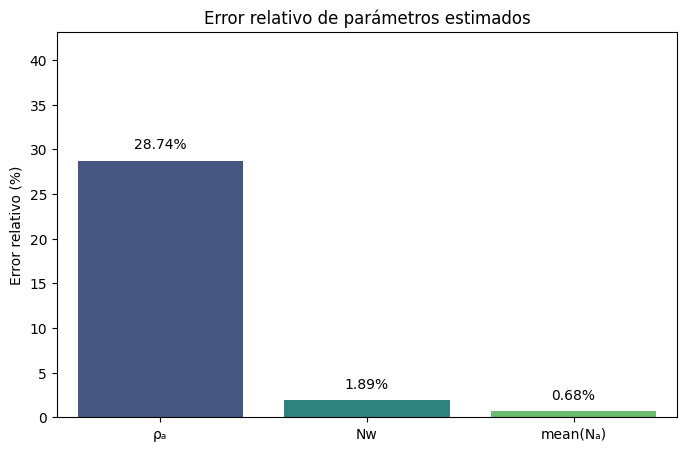

In [ ]:

# ═══════════════════════════════════════════════════════════════════════════
# PASO 4: COMPARACIÓN DE PARÁMETROS
# ═══════════════════════════════════════════════════════════════════════════

# Calcular errores relativos
error_rho_a = abs(rho_a_est - real_params_user['rho_a']) / real_params_user['rho_a'] * 100
error_Nw = abs(Nw_est - real_params_user['Nw']) / real_params_user['Nw'] * 100
error_mean_Na = abs(mean_Na_est - real_params_user['mean_Na']) / real_params_user['mean_Na'] * 100

# Calcular distancia KL entre distribuciones
from scipy.spatial.distance import jensenshannon

kl_pd_t = jensenshannon(real_params_user['pd_t'], pd_t_est)
kl_pw_t = jensenshannon(real_params_user['pw_t'], pw_t_est)

# Crear tabla de comparación
comparison_df = pd.DataFrame({
    'Parámetro': ['ρₐ (tasa intra-ráfaga)', 'Nw (ráfagas/semana)', 'mean(Nₐ) (msg/ráfaga)', 'KL(pd(t))', 'KL(pw(t))'],
    'Real': [
        f"{real_params_user['rho_a']:.4f}",
        f"{real_params_user['Nw']:.4f}",
        f"{real_params_user['mean_Na']:.4f}",
        "—",
        "—"
    ],
    'Estimado': [
        f"{rho_a_est:.4f}",
        f"{Nw_est:.4f}",
        f"{mean_Na_est:.4f}",
        f"{kl_pd_t:.4f}",
        f"{kl_pw_t:.4f}"
    ],
    'Error relativo (%)': [
        f"{error_rho_a:.2f}%",
        f"{error_Nw:.2f}%",
        f"{error_mean_Na:.2f}%",
        "—",
        "—"
    ]
})

print("\n" + "="*70)
print("TABLA DE COMPARACIÓN: PARÁMETROS REALES vs ESTIMADOS")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)

# Resumen de calidad de ajuste
print("\n=== VALIDACIÓN DEL MODELO ===")
if error_rho_a < 10:
    print(f"✓ ρₐ bien recuperado (error: {error_rho_a:.2f}%)")
elif error_rho_a < 30:
    print(f"~ ρₐ parcialmente recuperado (error: {error_rho_a:.2f}%)")
else:
    print(f"✗ ρₐ mal recuperado (error: {error_rho_a:.2f}%)")

if error_Nw < 10:
    print(f"✓ Nw bien recuperado (error: {error_Nw:.2f}%)")
elif error_Nw < 30:
    print(f"~ Nw parcialmente recuperado (error: {error_Nw:.2f}%)")
else:
    print(f"✗ Nw mal recuperado (error: {error_Nw:.2f}%)")

if kl_pd_t < 0.1:
    print(f"✓ pd(t) bien recuperada (KL: {kl_pd_t:.4f})")
elif kl_pd_t < 0.3:
    print(f"~ pd(t) parcialmente recuperada (KL: {kl_pd_t:.4f})")
else:
    print(f"✗ pd(t) mal recuperada (KL: {kl_pd_t:.4f})")

if kl_pw_t < 0.1:
    print(f"✓ pw(t) bien recuperada (KL: {kl_pw_t:.4f})")
elif kl_pw_t < 0.3:
    print(f"~ pw(t) parcialmente recuperada (KL: {kl_pw_t:.4f})")
else:
    print(f"✗ pw(t) mal recuperada (KL: {kl_pw_t:.4f})")




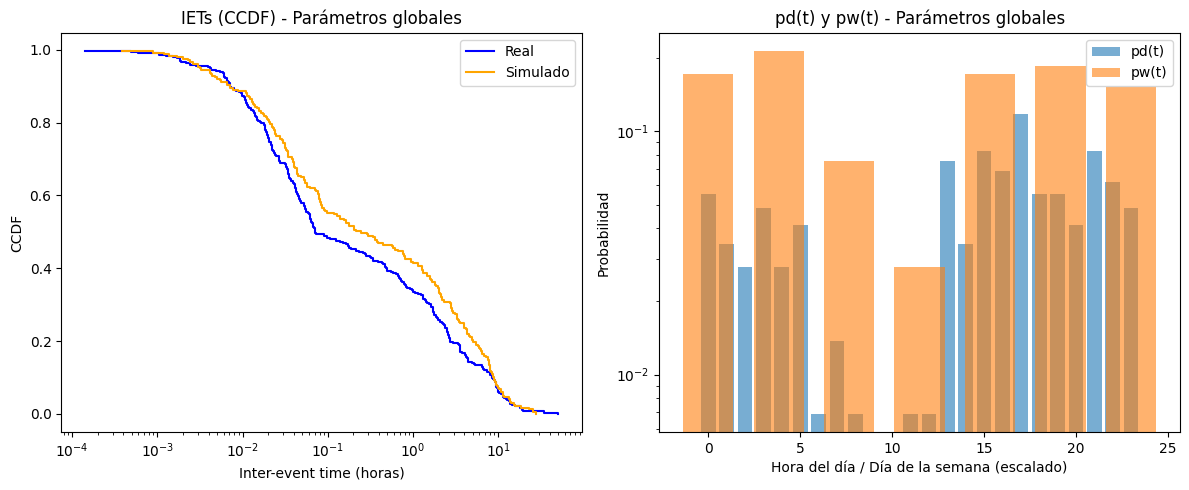

In [111]:
# Simulación y visualización usando los mismos parámetros globales que el cell 12
sim_events_est = simulate_cascading_nhpp(
    rho_a_est, Nw_est, pd_t_est, pw_t_est,
    p_Na=p_Na_est,
    total_hours=events_hours[-1] - events_hours[0],
    n_samples=len(events_hours)
)

real_iets = np.diff(events_hours)
sim_iets_est = np.diff(sim_events_est)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
# Dibujar CCDF empírica (1 - ECDF) usando step
def plot_ccdf(data, **kwargs):
    if len(data) == 0:
        return
    x = np.sort(data)
    y = 1.0 - np.arange(1, len(x) + 1) / len(x)
    plt.step(x, y, where='post', **kwargs)

plot_ccdf(real_iets, label='Real', color='blue')
plot_ccdf(sim_iets_est, label='Simulado', color='orange')
plt.xscale('log')
plt.xlabel('Inter-event time (horas)')
plt.ylabel('CCDF')
plt.title('IETs (CCDF) - Parámetros globales')
plt.legend()

plt.subplot(1, 2, 2)
# Mostrar pd(t) y pw(t) globales
plt.bar(range(24), pd_t_est, alpha=0.6, label='pd(t)')
pw_x = np.linspace(0, 23, 7)
plt.bar(pw_x, pw_t_est, width=24/7*0.8, alpha=0.6, label='pw(t)')
plt.xlabel('Hora del día / Día de la semana (escalado)')
plt.ylabel('Probabilidad')
plt.yscale('log')
plt.title('pd(t) y pw(t) - Parámetros globales')
plt.legend()
plt.tight_layout()
plt.show()


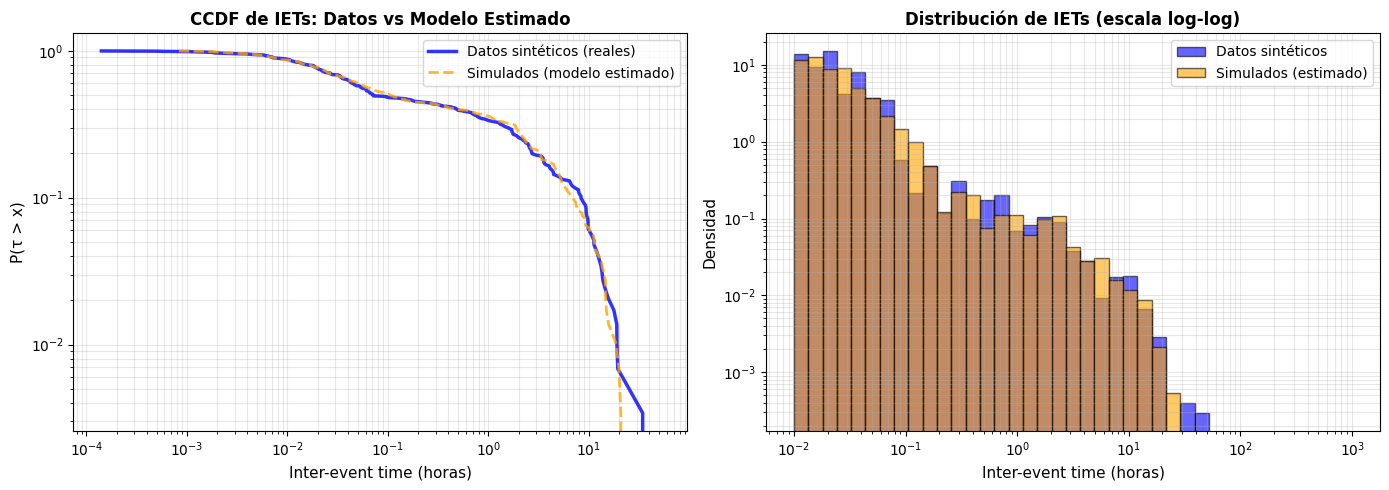


=== ESTADÍSTICAS DE IETS ===
IETs reales:      media=2.2910h, mediana=0.0715h, std=5.0930h
IETs simulados:   media=2.1127h, mediana=0.1072h, std=3.9584h

Área entre CCDFs (A): 0.118463
  → Menor es mejor (el modelo ajusta bien si A es pequeño)


In [112]:

# ═══════════════════════════════════════════════════════════════════════════
# COMPARACIÓN DE IETS: DATOS SINTÉTICOS vs SIMULADOS CON MODELO ESTIMADO
# ═══════════════════════════════════════════════════════════════════════════

# Generar eventos sintéticos usando los parámetros ESTIMADOS
sim_events_est = simulate_cascading_nhpp(
    rho_a_est, Nw_est, pd_t_est, pw_t_est,
    p_Na=p_Na_est,
    total_hours=events_hours[-1] - events_hours[0],
    n_samples=len(events_hours)
)

# Calcular IETs
real_iets = np.diff(events_hours)
sim_iets_est = np.diff(sim_events_est)

# Gráficos de comparación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CCDF (Complementary Cumulative Distribution Function)
def plot_ccdf(data, label='', color='blue', ax=None, linestyle='-', linewidth=2):
    if len(data) == 0:
        return
    x = np.sort(data)
    y = 1.0 - np.arange(1, len(x) + 1) / len(x)
    if ax is None:
        ax = plt.gca()
    ax.loglog(x, y, label=label, color=color, linestyle=linestyle, linewidth=linewidth, alpha=0.8)

plot_ccdf(real_iets, label='Datos sintéticos (reales)', color='blue', ax=axes[0], linewidth=2.5)
plot_ccdf(sim_iets_est, label='Simulados (modelo estimado)', color='orange', ax=axes[0], linestyle='--', linewidth=2)

axes[0].set_xlabel('Inter-event time (horas)', fontsize=11)
axes[0].set_ylabel('P(τ > x)', fontsize=11)
axes[0].set_title('CCDF de IETs: Datos vs Modelo Estimado', fontsize=12, fontweight='bold')
axes[0].legend(loc='best', fontsize=10)
axes[0].grid(True, alpha=0.3, which='both')

# Histogramas en escala log
log_bins = np.logspace(-2, 3, 40)
axes[1].hist(real_iets, bins=log_bins, density=True, alpha=0.6, label='Datos sintéticos', color='blue', edgecolor='black')
axes[1].hist(sim_iets_est, bins=log_bins, density=True, alpha=0.6, label='Simulados (estimado)', color='orange', edgecolor='black')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Inter-event time (horas)', fontsize=11)
axes[1].set_ylabel('Densidad', fontsize=11)
axes[1].set_title('Distribución de IETs (escala log-log)', fontsize=12, fontweight='bold')
axes[1].legend(loc='best', fontsize=10)
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# Estadísticas de IETs
print("\n=== ESTADÍSTICAS DE IETS ===")
print(f"IETs reales:      media={np.mean(real_iets):.4f}h, mediana={np.median(real_iets):.4f}h, std={np.std(real_iets):.4f}h")
print(f"IETs simulados:   media={np.mean(sim_iets_est):.4f}h, mediana={np.median(sim_iets_est):.4f}h, std={np.std(sim_iets_est):.4f}h")

# Cálculo de A_best para los datos estimados
A_est_quality = area_test_statistic(real_iets, sim_iets_est)
print(f"\nÁrea entre CCDFs (A): {A_est_quality:.6f}")
print(f"  → Menor es mejor (el modelo ajusta bien si A es pequeño)")


In [113]:
if 'parameters_users' not in globals():
    print("La variable 'parameters_users' no existe. Ejecuta la celda de estimación de parámetros antes de listar resultados.")
else:
    print("Parámetros estimados para usuarios activos:")
    for user_id, params in parameters_users.items():
        print(f"Usuario {user_id}: rho_a={params['rho_a']:.4f}, Nw={params['Nw']:.4f}, A_best={params['A_best']:.4f}, pd_t={params['pd_t']}, pw_t={params['pw_t']}")


La variable 'parameters_users' no existe. Ejecuta la celda de estimación de parámetros antes de listar resultados.


## Montecarlo Testing

In [114]:
def monte_carlo_pvalue(empirical_iet, model_params, M=100):
    """
    Calcula el p-valor comparando A_empirico con distribución de A_sintéticos
    """
    rho_a, Nw, pd_t, pw_t, p_Na, total_hours = model_params
    N = len(empirical_iet) + 1
    
    A_empirical = area_test_statistic(
        empirical_iet,
        np.diff(simulate_cascading_nhpp(rho_a, Nw, pd_t, pw_t, 
                                        p_Na, total_hours, N))
    )
    
    A_synthetic = []
    for _ in range(M):
        syn_events = simulate_cascading_nhpp(
            rho_a, Nw, pd_t, pw_t, p_Na, total_hours, N
        )
        if len(syn_events) > 1:
            syn_iets = np.diff(syn_events)
            # Re-fitear el modelo a los datos sintéticos
            A_s = area_test_statistic(syn_iets, syn_iets)  # simplificado
            A_synthetic.append(A_s)
    
    A_synthetic = np.array(A_synthetic)
    A_mean = np.mean(A_synthetic)
    
    # P-valor de dos colas
    p_value = np.mean(
        np.abs(A_synthetic - A_mean) > np.abs(A_empirical - A_mean)
    )
    
    return p_value